In [52]:
# CAR PRICE PREDICTION USING MACHINE LEARNING
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error


In [53]:
# Load Dataset
df = pd.read_csv("D:\srilatha\car data.csv")


In [54]:
print("First 5 Rows:")
print(df.head())



First 5 Rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [55]:
print("\nDataset Information:")
print(df.info())





Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [56]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [57]:
print("\nColumn Names:")
print(df.columns)



Column Names:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [58]:
# Feature Engineering
current_year = 2025
df["Car_Age"] = current_year - df["Year"]



In [59]:
# Drop Year column
df.drop("Year", axis=1, inplace=True)


In [60]:
# Data Preprocessing
# Remove Car_Name
df.drop("Car_Name", axis=1, inplace=True)

In [61]:
# Encode categorical columns
for col in ["Fuel_Type", "Selling_type", "Transmission"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("\nProcessed Data:")
print(df.head())



Processed Data:
   Selling_Price  Present_Price  Driven_kms  Fuel_Type  Selling_type  \
0           3.35           5.59       27000          2             0   
1           4.75           9.54       43000          1             0   
2           7.25           9.85        6900          2             0   
3           2.85           4.15        5200          2             0   
4           4.60           6.87       42450          1             0   

   Transmission  Owner  Car_Age  
0             1      0       11  
1             1      0       12  
2             1      0        8  
3             1      0       14  
4             1      0       11  


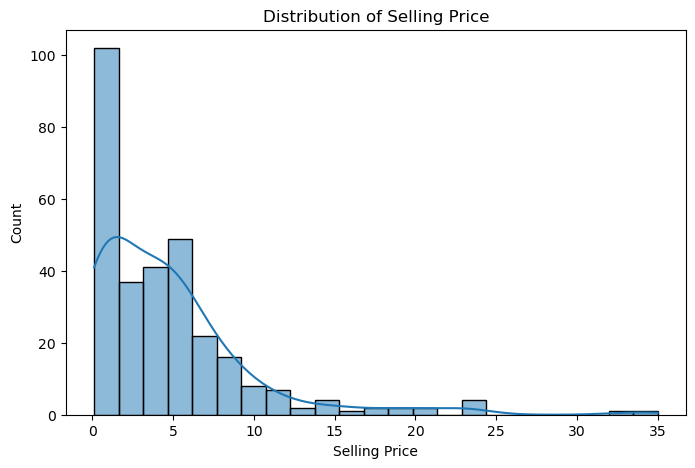

In [33]:
# Visualization 1
# Selling Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()



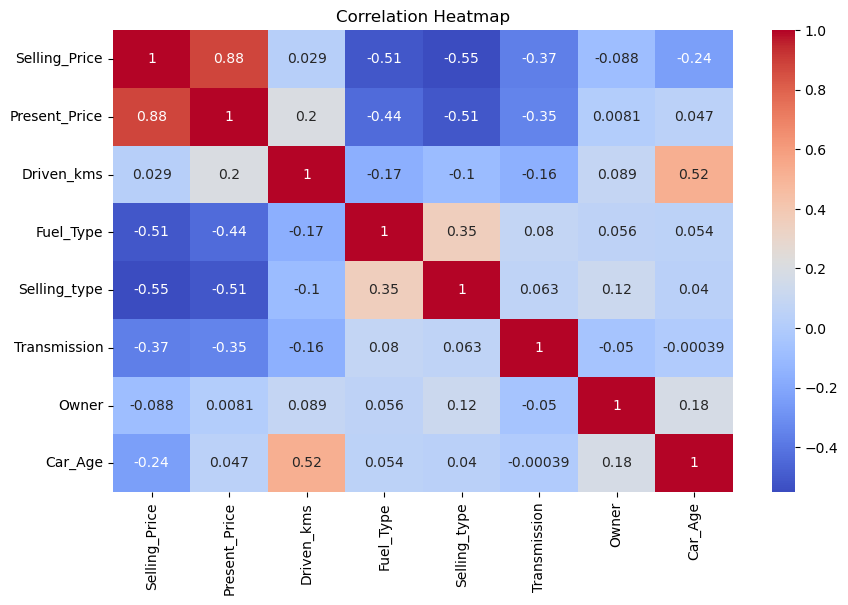

In [34]:
# Visualization 2
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


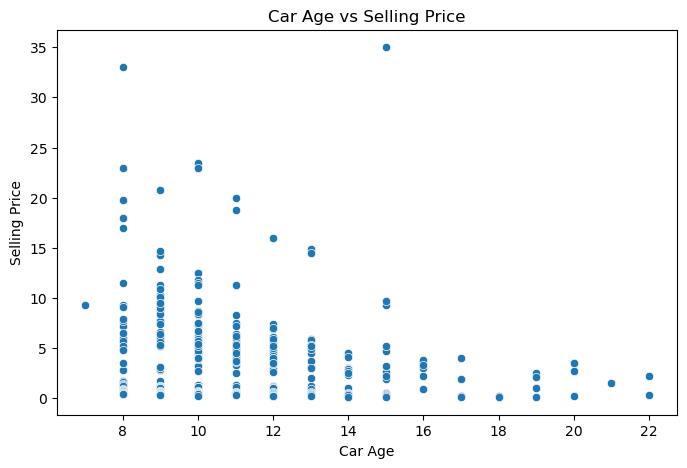

In [35]:
# Visualization 3
# Car Age vs Selling Price
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Car_Age"], y=df["Selling_Price"])
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()


In [36]:
# Features and Target
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)




Features Shape: (301, 7)
Target Shape: (301,)


In [37]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)




Training Data Shape: (240, 7)
Testing Data Shape: (61, 7)


In [38]:
# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Trained Successfully!")




Model Trained Successfully!


In [39]:
# Prediction
y_pred = model.predict(X_test)

print("\nFirst 5 Predictions:")
print(y_pred[:5])


First 5 Predictions:
[ 2.96562958  8.30085782  6.05782751 -1.46736816  9.25705687]


In [42]:
# Model Evaluation
import numpy as np
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)



Model Evaluation
MAE : 1.221932362175384
MSE : 3.5315798889686314
RMSE: 1.879249820797818
R2 Score: 0.846690241966383


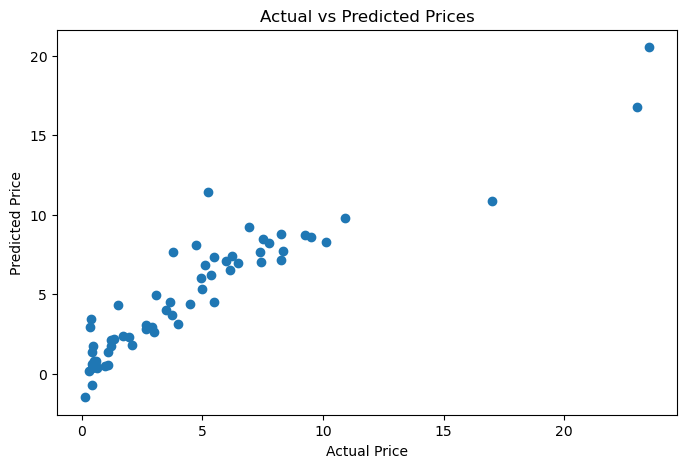

In [43]:
# Visualization 4
# Actual vs Predicted Prices
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()



In [44]:
# Single Car Price Prediction
sample = X.iloc[[0]]

predicted_price = model.predict(sample)

print("\nPredicted Price for Sample Car:")
print(predicted_price[0])



Predicted Price for Sample Car:
3.9640582081645706


In [2]:
print("\nProject Completed Successfully!")


Project Completed Successfully!
